In [ ]:
!pip install datasets transformers scikit-learn torch pandas numpy

In [ ]:
import pandas as pd
import numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt

from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from transformers import AutoTokenizer
from transformers import AutoModelForSequenceClassification, Trainer, TrainingArguments
from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix

In [ ]:
dataset = load_dataset("TheFinAI/daily_news")

df_list = []
for split in dataset.keys():
    temp_df = dataset[split].to_pandas()
    temp_df["asset_name"] = split
    df_list.append(temp_df)

df = pd.concat(df_list, ignore_index=True)

print("Shape:", df.shape)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/BTC-00000-of-00001.parquet:   0%|          | 0.00/1.07M [00:00<?, ?B/s]

data/TSLA-00000-of-00001.parquet:   0%|          | 0.00/832k [00:00<?, ?B/s]

data/MSFT-00000-of-00001.parquet:   0%|          | 0.00/707k [00:00<?, ?B/s]

...

Generating AMZN split:   0%|          | 0/270 [00:00<?, ? examples/s]

Generating GOOGL split:   0%|          | 0/270 [00:00<?, ? examples/s]

Generating META split:   0%|          | 0/270 [00:00<?, ? examples/s]

Generating NVDA split:   0%|          | 0/270 [00:00<?, ? examples/s]

Shape: (3240, 9)


In [ ]:
def process_news(x):
    if isinstance(x, (list, np.ndarray)):
        return " ".join(map(str, x))
    return ""

df["news_text"] = df["news"].apply(process_news)

In [ ]:
df = df.dropna(subset=["future_price_diff"])

In [ ]:
df["label"] = pd.qcut(
    df["future_price_diff"],
    q=3,
    labels=[0, 1, 2]
)

df["label"] = df["label"].astype(int)

print(df["label"].value_counts())

label
0    1076
2    1076
1    1076
Name: count, dtype: int64


In [ ]:
df["text"] = (
    "Financial news about " + df["asset_name"].astype(str) + ". " +
    df["news_text"].astype(str)
)

In [ ]:
def clean_text(x):
    if x is None:
        return ""
    if isinstance(x, float):
        return ""
    return str(x)

df["text"] = df["text"].apply(clean_text)

df = df[df["text"].str.strip() != ""]

In [ ]:
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")

split_idx = int(0.8 * len(df))

train_df = df.iloc[:split_idx]
val_df = df.iloc[split_idx:]

print(train_df.shape, val_df.shape)

(2582, 12) (646, 12)


In [ ]:
vectorizer = TfidfVectorizer(max_features=3000)

X_train = vectorizer.fit_transform(train_df["text"])
X_val = vectorizer.transform(val_df["text"])

model_lr = LogisticRegression(max_iter=200)
model_lr.fit(X_train, train_df["label"])

preds = model_lr.predict(X_val)

In [ ]:
print("Baseline Results:")
print(classification_report(val_df["label"], preds))

Baseline Results:
              precision    recall  f1-score   support

           0       0.36      0.34      0.35       216
           1       0.43      0.50      0.46       203
           2       0.36      0.33      0.34       227

    accuracy                           0.38       646
   macro avg       0.38      0.39      0.38       646
weighted avg       0.38      0.38      0.38       646



In [ ]:
model_name = "bert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)

train_encodings = tokenizer(
    list(train_df["text"]),
    truncation=True,
    padding=True,
    max_length=256
)

val_encodings = tokenizer(
    list(val_df["text"]),
    truncation=True,
    padding=True,
    max_length=256
)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
import torch

class FinancialDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels.tolist()

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

In [ ]:
train_dataset = FinancialDataset(train_encodings, train_df["label"])
val_dataset = FinancialDataset(val_encodings, val_df["label"])

In [18]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3
)

training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=2,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    learning_rate=2e-5,
    logging_dir="./logs",
    fp16=True
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
)

trainer.train()

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will 

Step,Training Loss
500,1.101142


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss
500,1.101142
1000,1.050631


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1292, training_loss=1.0628198676803164, metrics={'train_runtime': 15772.058, 'train_samples_per_second': 0.327, 'train_steps_per_second': 0.082, 'total_flos': 679358844573696.0, 'train_loss': 1.0628198676803164, 'epoch': 2.0})

In [19]:
predictions = trainer.predict(val_dataset)
y_pred = predictions.predictions.argmax(axis=1)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [20]:
print("Transformer Results:")
print(classification_report(val_df["label"], y_pred))

Transformer Results:
              precision    recall  f1-score   support

           0       0.49      0.18      0.26       216
           1       0.44      0.72      0.54       203
           2       0.45      0.46      0.46       227

    accuracy                           0.45       646
   macro avg       0.46      0.45      0.42       646
weighted avg       0.46      0.45      0.42       646



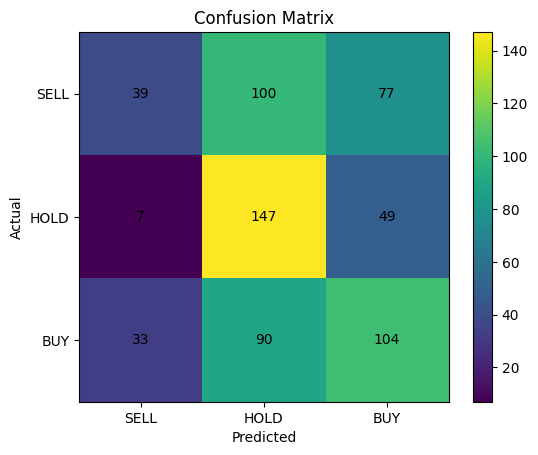

In [25]:
cm = confusion_matrix(val_df["label"], y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

labels = ["SELL", "HOLD", "BUY"]
plt.xticks(np.arange(3), labels)
plt.yticks(np.arange(3), labels)

plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(3):
    for j in range(3):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

In [21]:
import torch

def predict(news, company):
    text = "Financial news about " + company + ". " + news

    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
    outputs = model(**inputs)

    pred = torch.argmax(outputs.logits, dim=1).item()

    mapping = {0: "SELL", 1: "HOLD", 2: "BUY"}
    return mapping[pred]

In [28]:
print(predict(
    "Company reports strong earnings growth",
    "AAPL"
))

HOLD


In [29]:
model.save_pretrained("./model")
tokenizer.save_pretrained("./model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./model/tokenizer_config.json', './model/tokenizer.json')